Final Test Accuracy: 92.50%


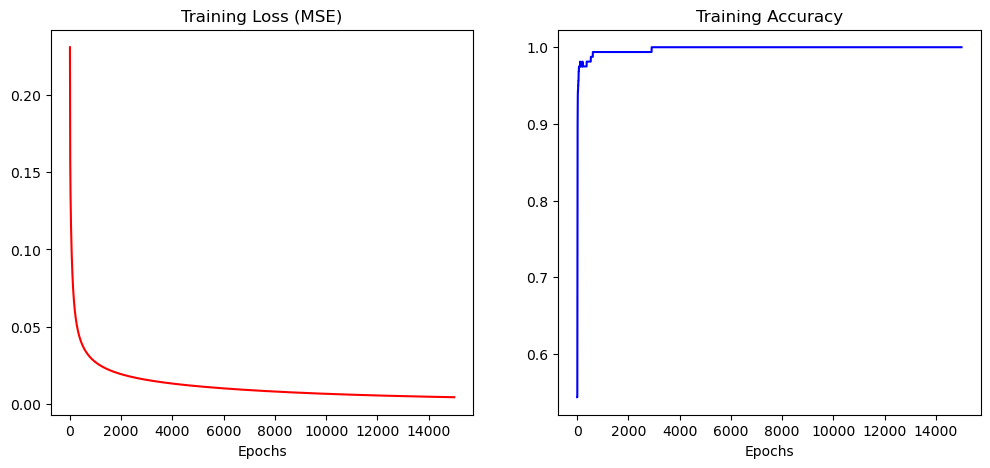

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and Preprocess Data
df = pd.read_csv('ANN.csv')
X = df[['Feature1', 'Feature2']].values
y = df['Target'].values.reshape(-1, 1)

# Split and Normalize
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. ANN Implementation from Scratch
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, lr=0.5):
        # Xavier initialization for weights
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = lr
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def sigmoid_derivative(self, x):
        return x * (1 - x)
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, output):
        m = y.shape[0]
        # Calculate gradients at output layer
        d_output = (output - y) * self.sigmoid_derivative(output)
        
        # Calculate gradients at hidden layer
        d_hidden = d_output.dot(self.W2.T) * self.sigmoid_derivative(self.a1)
        
        # Update weights and biases (Gradient Descent)
        self.W2 -= self.a1.T.dot(d_output) * (self.lr / m)
        self.b2 -= np.sum(d_output, axis=0, keepdims=True) * (self.lr / m)
        self.W1 -= X.T.dot(d_hidden) * (self.lr / m)
        self.b1 -= np.sum(d_hidden, axis=0, keepdims=True) * (self.lr / m)

    def train(self, X, y, epochs=15000):
        losses, accuracies = [], []
        for i in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)
            
            # Record Loss (MSE) and Accuracy
            loss = np.mean(np.square(y - output))
            losses.append(loss)
            accuracy = np.mean((output > 0.5).astype(int) == y)
            accuracies.append(accuracy)
        return losses, accuracies

# 3. Train the Model
nn = NeuralNetwork(input_size=2, hidden_size=10, output_size=1, lr=0.5)
losses, accuracies = nn.train(X_train, y_train, epochs=15000)

# 4. Evaluate and Print Accuracy
test_output = nn.forward(X_test)
test_accuracy = np.mean((test_output > 0.5).astype(int) == y_test) * 100
print(f"Final Test Accuracy: {test_accuracy:.2f}%")

# 5. Plotting Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses, color='red')
plt.title('Training Loss (MSE)')
plt.xlabel('Epochs')

plt.subplot(1, 2, 2)
plt.plot(accuracies, color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.savefig('ann_results.png')

Final Test Accuracy: 92.50%


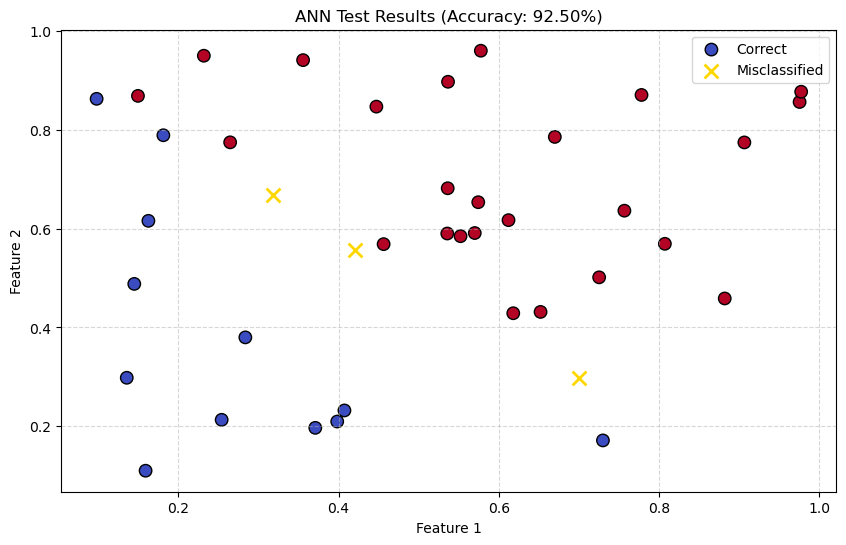

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv('ANN.csv')
X = df[['Feature1', 'Feature2']].values
y = df['Target'].values.reshape(-1, 1)

# 2. Split and Normalize (Same as training phase)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Perform Forward Pass on Test Set (Testing)
# (Assuming the 'nn' object is the trained model from the previous step)
test_probs = nn.forward(X_test_scaled)
predictions = (test_probs > 0.5).astype(int)

# 4. Calculate Final Accuracy in Percentage
accuracy = np.mean(predictions == y_test) * 100
print(f"Final Test Accuracy: {accuracy:.2f}%")

# 5. Graph Plotting: Visualization of Predictions
plt.figure(figsize=(10, 6))

# Identify correct and incorrect classifications
correct = (predictions == y_test).flatten()
incorrect = ~correct

# Plot Correct Predictions (Colored by actual label: Blue=0, Red=1)
plt.scatter(X_test[correct, 0], X_test[correct, 1], c=y_test[correct].flatten(), 
            cmap='coolwarm', marker='o', label='Correct', edgecolors='k', s=80)

# Highlight Incorrect Predictions
plt.scatter(X_test[incorrect, 0], X_test[incorrect, 1], c='gold', 
            marker='x', label='Misclassified', s=100, linewidth=2)

plt.title(f'ANN Test Results (Accuracy: {accuracy:.2f}%)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('test_accuracy_graph.png')